In [1]:
%pip install -U pyobjc-framework-Quartz pyobjc-framework-Vision

Note: you may need to restart the kernel to use updated packages.


In [36]:
import cv2
import numpy as np
import glob
import Quartz
import Vision
import CoreFoundation
from Cocoa import NSURL
from Foundation import NSDictionary, NSArray
import matplotlib.pyplot as plt

import requests as req
import re

from glob import glob
from tqdm import tqdm
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import bs4


In [37]:
prgrm=req.get("https://vinci2025.games.cg.jku.at/schedule/#papers-1").text
soup=bs4.BeautifulSoup(prgrm,"html.parser")

In [38]:
blocks = soup.select("div[id^=poster]")
[block.attrs["id"] for block in blocks]

['poster-session']

In [39]:
papers = []
for block in blocks:
    block_title = block.select_one(".has-x-large-font-size").get_text().strip()
    # f.write(f"## {block_title}\n")
    for paper in block.select(".has-small-font-size"):
        authors_tag = paper.select_one("em")
        if not authors_tag:
            continue
        authors = authors_tag.get_text().strip()
        title = paper.select_one("strong").get_text().strip()

        papers.append(
            {
                "title": title,
                "authors": re.split(r",| and ", authors),
            }
        )

In [40]:

df_papers = pd.DataFrame(papers)
df_papers.head()

,title,authors
0,Visual Exploration of Ontologies Supported by ...,"[Benedikt Kantz, Peter Waldert, Stefan Lenga..."
1,KnitSim: Knitting Simulation for Fabric Patter...,"[Benedikt Kantz, Peter Waldert, Tobias Schre..."
2,Introducing Modality De Re / De Dicto into Eul...,"[Yuka Tosaka, Yuri Sato]"
3,VR Coffee Break: Rhythmic Immersive Stimulatio...,"[Ximeng Zhang, Yue Qin, Yuyang Wang]"
4,Interactive Visualization Notebooks: A Use Cas...,"[Joshua Reibert, Matthias Pohl]"


In [41]:
import json
with open("posters.json", "w") as f:
    df_papers.to_json(f, indent=2, orient="records")

In [42]:
df_papers

,title,authors
0,Visual Exploration of Ontologies Supported by ...,"[Benedikt Kantz, Peter Waldert, Stefan Lenga..."
1,KnitSim: Knitting Simulation for Fabric Patter...,"[Benedikt Kantz, Peter Waldert, Tobias Schre..."
2,Introducing Modality De Re / De Dicto into Eul...,"[Yuka Tosaka, Yuri Sato]"
3,VR Coffee Break: Rhythmic Immersive Stimulatio...,"[Ximeng Zhang, Yue Qin, Yuyang Wang]"
4,Interactive Visualization Notebooks: A Use Cas...,"[Joshua Reibert, Matthias Pohl]"
5,Lighting Up Bianjing: An AI-Supported Interact...,"[Yuxiang Fan, Wanlin Zhang, Xing Luo]"


In [43]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
)
tfidf.fit(df_papers["title"].fillna(""))
tfidf.get_feature_names_out()

array(['ai', 'ai supported', 'an', 'an ai', 'and', 'and interactive',
       'attention', 'attention restoration', 'bianjing', 'bianjing an',
       'break', 'break rhythmic', 'by', 'by language', 'case', 'case in',
       'coffee', 'coffee break', 'de', 'de dicto', 'de re', 'diagrams',
       'diagrams implication', 'dicto', 'dicto into', 'engaging',
       'engaging visitors', 'euler', 'euler diagrams', 'exploration',
       'exploration of', 'fabric', 'fabric pattern', 'for',
       'for attention', 'for engaging', 'for fabric', 'heritage',
       'heritage lanterns', 'immersive', 'immersive stimulation',
       'implication', 'implication to', 'in', 'in space', 'interactive',
       'interactive lenses', 'interactive system',
       'interactive visualization', 'into', 'into euler', 'introducing',
       'introducing modality', 'knitsim', 'knitsim knitting', 'knitting',
       'knitting simulation', 'language', 'language models', 'lanterns',
       'lenses', 'lighting', 'lighting u

In [44]:
nn = NearestNeighbors(n_neighbors=1, metric="cosine").fit(
    tfidf.transform(
        df_papers["title"].fillna("") + " " + df_papers["authors"].str.join(" ").fillna("")
    )
)
result_dist, result_idx = nn.kneighbors(tfidf.transform(["T-SNE for Visualizing High-Dimensional Data"]))
df_papers.iloc[result_idx[0]]

,title,authors
1,KnitSim: Knitting Simulation for Fabric Patter...,"[Benedikt Kantz, Peter Waldert, Tobias Schre..."


In [45]:
def order_points(pts):
    """Rearrange coordinates to order:
    top-left, top-right, bottom-right, bottom-left"""
    rect = np.zeros((4, 2), dtype="float32")
    pts = np.array(pts)
    s = pts.sum(axis=1)
    # Top-left point will have the smallest sum.
    rect[0] = pts[np.argmin(s)]
    # Bottom-right point will have the largest sum.
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    # Top-right point will have the smallest difference.
    rect[1] = pts[np.argmin(diff)]
    # Bottom-left will have the largest difference.
    rect[3] = pts[np.argmax(diff)]
    # return the ordered coordinates
    return rect.astype("int").tolist()


def find_dest(pts):
    (tl, tr, br, bl) = pts
    # Finding the maximum width.
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # Finding the maximum height.
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))
    # Final destination co-ordinates.
    destination_corners = [[0, 0], [maxWidth, 0], [maxWidth, maxHeight], [0, maxHeight]]

    return order_points(destination_corners)


def scan(img, name=""):
    # Resize image to workable size
    dim_limit = 1920
    max_dim = max(img.shape)
    if max_dim > dim_limit:
        resize_scale = dim_limit / max_dim
        img = cv2.resize(img, None, fx=resize_scale, fy=resize_scale)
    # Create a copy of resized original image for later use
    orig_img = img.copy()
    # Repeated Closing operation to remove text from the document.
    kernel = np.ones((5, 5), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=3)
    # GrabCut
    mask = np.zeros(img.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    rect = (20, 20, img.shape[1] - 20, img.shape[0] - 20)
    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    img = img * mask2[:, :, np.newaxis]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (11, 11), 0)
    # Edge Detection.
    canny = cv2.Canny(gray, 0, 200)
    canny = cv2.dilate(canny, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))

    # Finding contours for the detected edges.
    contours, hierarchy = cv2.findContours(canny, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    # Keeping only the largest detected contour.
    page = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    # Detecting Edges through Contour approximation.
    # Loop over the contours.
    if len(page) == 0:
        return orig_img
    candidates = []
    for c in page:
        # Approximate the contour.
        epsilon = 0.02 * cv2.arcLength(c, True)
        corners = cv2.approxPolyDP(c, epsilon, True)
        area = cv2.contourArea(corners)
        # If our approximated contour has four points.
        if len(corners) == 4:
            candidates.append((corners, area))
    if len(candidates) == 0:
        return orig_img
    candidates.sort(key=lambda x: x[1], reverse=True)
    corners = candidates[0][0]
    print(candidates)
    # Sorting the corners and converting them to desired shape.
    corners = sorted(np.concatenate(corners).tolist())
    # For 4 corner points being detected.
    corners = order_points(corners)

    destination_corners = find_dest(corners)

    h, w = orig_img.shape[:2]
    # Getting the homography.
    M = cv2.getPerspectiveTransform(
        np.float32(corners), np.float32(destination_corners)
    )
    # Perspective transform using homography.
    final = cv2.warpPerspective(
        orig_img,
        M,
        (destination_corners[2][0], destination_corners[2][1]),
        flags=cv2.INTER_LINEAR,
    )
    return final

In [46]:
imgs = glob("figures/posters/initial/*.png")
# for img in tqdm(imgs):
#     print(img)
#     img_dat=cv2.imread(img)
#     final=scan(img_dat)
#     cv2.imwrite('out/'+img.split('/')[-1], final)
len(imgs)

7

In [47]:
def make_request_handler_img(results):
    """results: list to store results"""
    if not isinstance(results, list):
        raise ValueError("results must be a list")

    def handler(request, error):
        if error:
            print(f"Error! {error}")
        else:
            observations: "list[Vision.VNRecognizedTextObservation]" = request.results()
            for text_observation in observations:
                recognized_text = text_observation.topCandidates_(1)[0]
                corners = {
                    "tl": text_observation.topLeft(),
                    "tr": text_observation.topRight(),
                    "bl": text_observation.bottomLeft(),
                    "br": text_observation.bottomRight(),
                }
                corners = {k: (v.x, v.y) for k, v in corners.items()}
                results.append(
                    [recognized_text.string(), recognized_text.confidence(), corners]
                )

    return handler


def image_to_text(
    img_path, lang="eng"
) -> "list[tuple[str, float, dict[str,tuple[float,float]]]]":
    input_url = NSURL.fileURLWithPath_(img_path)

    input_image = Quartz.CIImage.imageWithContentsOfURL_(input_url)

    vision_options = NSDictionary.dictionaryWithDictionary_({})

    vision_handler = Vision.VNImageRequestHandler.alloc().initWithCIImage_options_(
        input_image, vision_options
    )
    results = []
    handler = make_request_handler_img(results)
    vision_request = Vision.VNRecognizeTextRequest.alloc().initWithCompletionHandler_(
        handler
    )
    # print(vision_request.recognitionLanguages())
    vision_request.setRecognitionLanguages_(
        NSArray.arrayWithArray_(
            [
                lang,
            ]
        )
    )
    # vision_request.setCustomWords_(NSArray.arrayWithArray_(['für',]))
    # print(type(vision_request.recognitionLanguages()))
    # print(vision_request.recognitionLanguages())
    vision_request.setUsesCPUOnly_(False)  # somehow improves accuracy??
    error = vision_handler.performRequests_error_([vision_request], None)

    return results

In [48]:
def find_dest_doc(pts):
    (tl, tr, br, bl) = pts
    # Finding the maximum width.
    widthA = np.sqrt(((br - bl) ** 2).sum())
    widthB = np.sqrt(((tr - tl) ** 2).sum())
    maxWidth = max(int(widthA), int(widthB))

    # Finding the maximum height.
    heightA = np.sqrt(((tr - br) ** 2).sum())
    heightB = np.sqrt(((tl - bl) ** 2).sum())
    maxHeight = max(int(heightA), int(heightB))
    # Final destination co-ordinates.
    destination_corners = [
        [0, 0],
        [maxWidth, 0],
        [0, maxHeight],
        [maxWidth, maxHeight],
    ]

    return destination_corners


def make_request_handler_doc(results):
    """results: list to store results"""
    if not isinstance(results, list):
        raise ValueError("results must be a list")

    def handler(request, error):
        if error:
            print(f"Error! {error}")
        else:
            observations = request.results()
            for obs in observations:
                # print(obs)
                # print(obs.bottomLeft())
                # print(obs.bottomRight())
                bbox = obs.boundingBox()
                corners = {
                    "tl": obs.topLeft(),
                    "tr": obs.topRight(),
                    "bl": obs.bottomLeft(),
                    "br": obs.bottomRight(),
                }
                corners = {k: (v.x, v.y) for k, v in corners.items()}
                results.append(
                    {
                        "bbox": corners,
                        "bbox_obj": bbox,
                        "conf": obs.confidence(),
                    }
                )

    return handler


def image_doc_handler(img_path: str) -> str:
    input_url = NSURL.fileURLWithPath_(img_path)

    input_image = Quartz.CIImage.imageWithContentsOfURL_(input_url)

    vision_options = NSDictionary.dictionaryWithDictionary_({})

    vision_handler = Vision.VNImageRequestHandler.alloc().initWithCIImage_options_(
        input_image, vision_options
    )
    results = []
    handler = make_request_handler_doc(results)
    vision_request = (
        Vision.VNDetectDocumentSegmentationRequest.alloc().initWithCompletionHandler_(
            handler
        )
    )
    # print(vision_request.recognitionLanguages())
    # vision_request.setRecognitionLanguages_(NSArray.arrayWithArray_([lang,]))
    # vision_request.setCustomWords_(NSArray.arrayWithArray_(['für',]))
    # print(type(vision_request.recognitionLanguages()))
    # print(vision_request.recognitionLanguages())
    # vision_request.setUsesCPUOnly_(False) # somehow improves accuracy??
    error = vision_handler.performRequests_error_([vision_request], None)

    return results


res = image_doc_handler(imgs[0])
res

[{'bbox': {'tl': (0.1597222238779068, 0.83984375),
   'tr': (0.9166666865348816, 0.9296875),
   'bl': (0.2013888955116272, 0.234375),
   'br': (0.8194444179534912, 0.0859375)},
  'bbox_obj': <CoreFoundation.CGRect origin=<CoreFoundation.CGPoint x=0.1597222238779068 y=0.0859375> size=<CoreFoundation.CGSize width=0.7569444626569748 height=0.84375>>,
  'conf': 0.9900000095367432}]

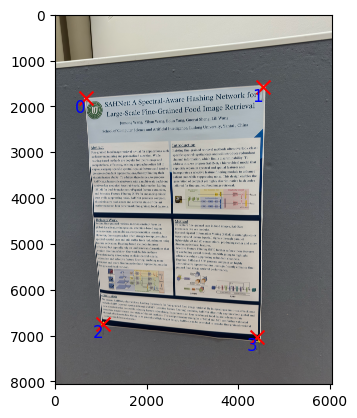

In [49]:
img = imgs[1]
res = image_doc_handler(img)
img_dat = cv2.imread(img)
src=np.array([
    res[0]["bbox"]["tl"],
    res[0]["bbox"]["tr"],
    res[0]["bbox"]["bl"],
    res[0]["bbox"]["br"],
])
# src = np.array([list(p) for p in res[0]["bbox"].values()])
dst = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ]
)
shape = np.flip(img_dat.shape[:2])
src = src * shape
dst_scaled = find_dest_doc(src)
src_flipped_y = np.copy(src)
src_flipped_y[:, 1] = shape[1] - src[:, 1]
plt.imshow(cv2.cvtColor(img_dat, cv2.COLOR_BGR2RGB))
plt.scatter(src_flipped_y[:, 0], src_flipped_y[:, 1], marker="x", color="red", s=100)
for i, (x, y) in enumerate(src_flipped_y):
    plt.text(x, y, str(i), color="blue", fontsize=12, ha="right", va="top")

In [50]:
dst_scaled

[[0, 0], [3872, 0], [0, 6402], [3872, 6402]]

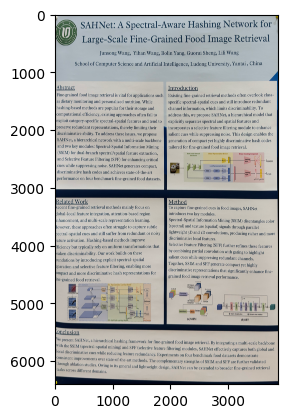

In [51]:
dst_mtx= np.array(dst_scaled).astype("float32")
src_mtx = np.array(src_flipped_y).astype("float32")
M = cv2.getPerspectiveTransform(src_mtx,dst_mtx)
dst_size=tuple(dst_mtx.max(axis=0).astype('int').tolist())

warped = cv2.warpPerspective(img_dat, M, dst_size, flags=cv2.INTER_LINEAR)
# warped_flipped=cv2.
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))

In [52]:
dst_size

(3872, 6402)

In [53]:
def extract_poster_img(img: str):
    res = image_doc_handler(img)
    img_dat = cv2.imread(img)
    src = np.array([list(p) for p in res[0]["bbox"].values()])
    shape = np.flip(img_dat.shape[:2])
    src = src * shape
    dst_scaled = find_dest_doc(src)
    src_flipped_y = np.copy(src)
    src_flipped_y[:, 1] = shape[1] - src[:, 1]

    dst_mtx= np.array(dst_scaled).astype("float32")
    src_mtx = np.array(src_flipped_y).astype("float32")
    M = cv2.getPerspectiveTransform(src_mtx,dst_mtx)
    dst_size=tuple(dst_mtx.max(axis=0).astype('int').tolist())

    warped = cv2.warpPerspective(img_dat, M, dst_size, flags=cv2.INTER_LINEAR)

    return warped


for img in tqdm(imgs):
    img_path = Path(img)
    warped = extract_poster_img(img)
    target_path = img_path.parent.parent / "warped" / img_path.parts[-1]

    cv2.imwrite(str(target_path), warped)

100%|██████████| 7/7 [00:35<00:00,  5.13s/it]


In [54]:
def authors_text(texts):
    results = texts
    for textbox in results:
        commas = (
            textbox[0].count(",")
            + textbox[0].count("and")
            + textbox[0].count("&")
            + textbox[0].count(".")
        )

        textbox.append(commas)
    results.sort(key=lambda x: x[-1], reverse=True)
    return results[0][0] if len(results) else ""


def biggest_text(texts):
    results = texts
    for textbox in results:
        dims = textbox[2]
        poss = np.array([dims["tl"], dims["tr"], dims["br"], dims["bl"]]).astype(
            np.float32
        )
        area = cv2.contourArea(poss)
        textbox.append(area)
    results.sort(key=lambda x: x[-1], reverse=True)
    return results[0][0] if len(results) else ""

In [55]:
outs = glob("figures/posters/warped/*.png")
for img in tqdm(outs):
    img_dat = cv2.imread(img)
    # downscale image
    dim_limit = 1080
    max_dim = max(img_dat.shape)
    if max_dim > dim_limit:
        resize_scale = dim_limit / max_dim
        img_dat = cv2.resize(img_dat, None, fx=resize_scale, fy=resize_scale)
    cv2.imwrite("figures/posters/reduced/" + img.split("/")[-1], img_dat)

100%|██████████| 7/7 [00:03<00:00,  2.02it/s]


In [56]:
data = []

for img in tqdm(outs):
    texts = image_to_text(img, "eng")
    all_texts= "\n".join([t[0] for t in texts])
    title = biggest_text(texts)
    authors = authors_text(texts)

    # print(title, authors)
    data.append(
        {
            "title": title,
            "authors": authors,
            "texts": texts,
            "all_texts": all_texts,
            "img": img,
            "img_reduced": Path(img).parent.parent / "reduced" / Path(img).parts[-1],
        }
    )

100%|██████████| 7/7 [00:21<00:00,  3.01s/it]


In [57]:
data_df=pd.DataFrame(data)
data_df

,title,authors,texts,all_texts,img,img_reduced
0,VINCI 2025 Lighting Up Bianjing: An Al-Support...,"for brightness, prosperity, and harmony in Chi...","[[for brightness, prosperity, and harmony in C...",VINCI 2025 Lighting Up Bianjing: An Al-Support...,figures/posters/warped/IMG_5742.png,figures/posters/reduced/IMG_5742.png
1,SAHNet: A Spectral-Aware Hashing Network for,School of Computer Science and Artificial Inte...,[[School of Computer Science and Artificial In...,UNIVE\nSAHNet: A Spectral-Aware Hashing Networ...,figures/posters/warped/IMG_5741.png,figures/posters/reduced/IMG_5741.png
2,for Urban Art Spaces Using Markerless Tracking,17) M. Patton Qualitative Research& Evaluation...,[[17) M. Patton Qualitative Research& Evaluati...,Interactive Augmented Reality Experiences\nfor...,figures/posters/warped/IMG_5740.png,figures/posters/reduced/IMG_5740.png
3,KNITSIM: KNITTING SIMULATION FOR FABRIC PATTER...,"(2) Vidya Narayanan, Kui Wa, Cem Yuksel and Ja...","[[(2) Vidya Narayanan, Kui Wa, Cem Yuksel and ...",KNITSIM: KNITTING SIMULATION FOR FABRIC PATTER...,figures/posters/warped/IMG_5735.png,figures/posters/reduced/IMG_5735.png
4,VISUAL EXPLORATION OF ONTOLOGIES SUPPORTED BY,"• Visualize in Circle Packing (2], enabling an...","[[• Visualize in Circle Packing (2], enabling ...",VISUAL EXPLORATION OF ONTOLOGIES SUPPORTED BY\...,figures/posters/warped/IMG_5737.png,figures/posters/reduced/IMG_5737.png
5,Interactive Visualization Notebooks:,"• custom, powerful, and interactive widgets with","[[• custom, powerful, and interactive widgets ...",Interactive Visualization Notebooks:\nA Use Ca...,figures/posters/warped/IMG_5739.png,figures/posters/reduced/IMG_5739.png
6,Introducing Modality De Re / De Dicto into Eul...,(sato.yuri@ocha.ac.jp) *: Ochanomizu Universit...,[[(sato.yuri@ocha.ac.jp) *: Ochanomizu Univers...,Introducing Modality De Re / De Dicto into Eul...,figures/posters/warped/IMG_5738.png,figures/posters/reduced/IMG_5738.png


In [58]:
data_df["url"] = ""
data_df["abstract"] = ""

In [59]:
df_papers

,title,authors
0,Visual Exploration of Ontologies Supported by ...,"[Benedikt Kantz, Peter Waldert, Stefan Lenga..."
1,KnitSim: Knitting Simulation for Fabric Patter...,"[Benedikt Kantz, Peter Waldert, Tobias Schre..."
2,Introducing Modality De Re / De Dicto into Eul...,"[Yuka Tosaka, Yuri Sato]"
3,VR Coffee Break: Rhythmic Immersive Stimulatio...,"[Ximeng Zhang, Yue Qin, Yuyang Wang]"
4,Interactive Visualization Notebooks: A Use Cas...,"[Joshua Reibert, Matthias Pohl]"
5,Lighting Up Bianjing: An AI-Supported Interact...,"[Yuxiang Fan, Wanlin Zhang, Xing Luo]"


In [60]:
for i, row in tqdm(data_df.iterrows(), total=len(data_df)):
    title = row["title"]
    authors = row["authors"]
    k_nn=1
    
    result_dist, result_idx = nn.kneighbors(
        tfidf.transform([row["all_texts"]])
    )
    result=df_papers.iloc[result_idx[0]]
    
    # data_df.loc[i, "url"] = result["link"].values[0]
    data_df.loc[i, "title"] = result["title"].values[0]
    data_df.loc[i, "authors"] = result["authors"].str.join(", ").values[0]
    # data_df.loc[i, "url"] = result["url"].values[0]
    # data_df.loc[i, "abstract"] = result["abstract"].values[0]

100%|██████████| 7/7 [00:00<00:00, 395.03it/s]


In [61]:
data_df

,title,authors,texts,all_texts,img,img_reduced,url,abstract
0,Lighting Up Bianjing: An AI-Supported Interact...,"Yuxiang Fan, Wanlin Zhang, Xing Luo","[[for brightness, prosperity, and harmony in C...",VINCI 2025 Lighting Up Bianjing: An Al-Support...,figures/posters/warped/IMG_5742.png,figures/posters/reduced/IMG_5742.png,,
1,Visual Exploration of Ontologies Supported by ...,"Benedikt Kantz, Peter Waldert, Stefan Lengau...",[[School of Computer Science and Artificial In...,UNIVE\nSAHNet: A Spectral-Aware Hashing Networ...,figures/posters/warped/IMG_5741.png,figures/posters/reduced/IMG_5741.png,,
2,Visual Exploration of Ontologies Supported by ...,"Benedikt Kantz, Peter Waldert, Stefan Lengau...",[[17) M. Patton Qualitative Research& Evaluati...,Interactive Augmented Reality Experiences\nfor...,figures/posters/warped/IMG_5740.png,figures/posters/reduced/IMG_5740.png,,
3,KnitSim: Knitting Simulation for Fabric Patter...,"Benedikt Kantz, Peter Waldert, Tobias Schrec...","[[(2) Vidya Narayanan, Kui Wa, Cem Yuksel and ...",KNITSIM: KNITTING SIMULATION FOR FABRIC PATTER...,figures/posters/warped/IMG_5735.png,figures/posters/reduced/IMG_5735.png,,
4,Visual Exploration of Ontologies Supported by ...,"Benedikt Kantz, Peter Waldert, Stefan Lengau...","[[• Visualize in Circle Packing (2], enabling ...",VISUAL EXPLORATION OF ONTOLOGIES SUPPORTED BY\...,figures/posters/warped/IMG_5737.png,figures/posters/reduced/IMG_5737.png,,
5,Interactive Visualization Notebooks: A Use Cas...,"Joshua Reibert, Matthias Pohl","[[• custom, powerful, and interactive widgets ...",Interactive Visualization Notebooks:\nA Use Ca...,figures/posters/warped/IMG_5739.png,figures/posters/reduced/IMG_5739.png,,
6,Introducing Modality De Re / De Dicto into Eul...,"Yuka Tosaka, Yuri Sato",[[(sato.yuri@ocha.ac.jp) *: Ochanomizu Univers...,Introducing Modality De Re / De Dicto into Eul...,figures/posters/warped/IMG_5738.png,figures/posters/reduced/IMG_5738.png,,


In [62]:
%pip install -U pylatex

Note: you may need to restart the kernel to use updated packages.


In [63]:
from pylatex.utils import escape_latex

In [64]:
with open("./posters.md", "w") as f:
    f.write("| **Poster** | **Title** | **Information** | \n")
    separator="| -- | -- | -- | \n"
    f.write(separator)
    lines=[
        f'| ![poster](figures/posters/reduced/{poster["img"].split("/")[-1]}) | {poster["title"].replace("|", " ")} | *{escape_latex(poster["authors"].replace("|", " ")).strip()}* | \n' for i,poster in data_df.iterrows()
    ]
    f.write("".join(lines))
    